In [1]:
# DAY 31 - BUILDING CUSTOMER PERSONAS FROM BEHAVIORAL DATA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Day 31 libraries imported successfully!")

Day 31 libraries imported successfully!


In [2]:
# Load the final customer segmentation data from Day 30

df = pd.read_csv("../Day30/customer_segments_final.csv")

print("Customer segmentation data loaded successfully!")
print("Dataset shape:", df.shape)

print("\nColumns available:")
print(df.columns.tolist())

df.head()

Customer segmentation data loaded successfully!
Dataset shape: (795, 9)

Columns available:
['customer_name', 'total_sales', 'total_quantity', 'total_profit', 'average_discount', 'average_shipping_days', 'number_of_orders', 'cluster', 'segment_name']


,customer_name,total_sales,total_quantity,total_profit,average_discount,average_shipping_days,number_of_orders,cluster,segment_name
0,Aaron Bergman,24646.0,301,4683.20800,0.110112,3.707865,89,0,High-Value Customers
1,Aaron Hawkins,20759.0,231,2450.92904,0.160929,3.464286,56,0,High-Value Customers
2,Aaron Smayling,14207.0,211,369.16180,0.167667,4.433333,60,1,Regular Customers
3,Adam Bellavance,20189.0,262,4979.97690,0.131765,3.514706,68,0,High-Value Customers
4,Adam Hart,21720.0,293,1902.03342,0.093238,3.654762,84,0,High-Value Customers


In [3]:
# Check the customer segments

print("========== CUSTOMER SEGMENT COUNTS ==========\n")

segment_counts = df["segment_name"].value_counts()

print(segment_counts)

print("\nTotal customers:", len(df))

========== CUSTOMER SEGMENT COUNTS ==========

segment_name
Regular Customers       457
High-Value Customers    338
Name: count, dtype: int64

Total customers: 795


In [4]:
# Analyze customer behavior for each persona

persona_profile = df.groupby("segment_name").agg(
    average_sales=("total_sales", "mean"),
    average_quantity=("total_quantity", "mean"),
    average_profit=("total_profit", "mean"),
    average_discount=("average_discount", "mean"),
    average_shipping_days=("average_shipping_days", "mean"),
    average_orders=("number_of_orders", "mean"),
    customer_count=("customer_name", "count")
).round(2)

print("========== CUSTOMER PERSONA PROFILES ==========\n")

display(persona_profile)

========== CUSTOMER PERSONA PROFILES ==========



,average_sales,average_quantity,average_profit,average_discount,average_shipping_days,average_orders,customer_count
segment_name,,,,,,,
High-Value Customers,20109.22,267.53,2616.06,0.14,3.95,75.81,338
Regular Customers,12792.09,192.31,1279.66,0.15,3.99,56.16,457


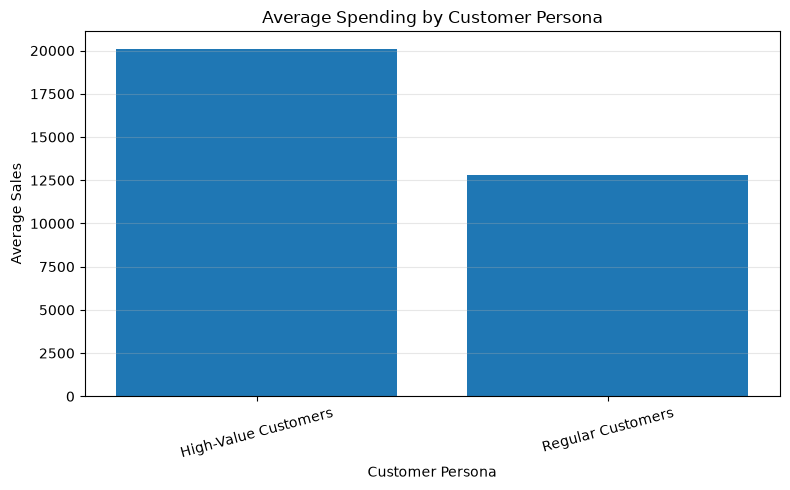

Persona spending chart created successfully!


In [5]:
# Compare average spending across customer personas

plt.figure(figsize=(8, 5))

plt.bar(
    persona_profile.index,
    persona_profile["average_sales"]
)

plt.xlabel("Customer Persona")
plt.ylabel("Average Sales")
plt.title("Average Spending by Customer Persona")

plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "persona_spending.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Persona spending chart created successfully!")

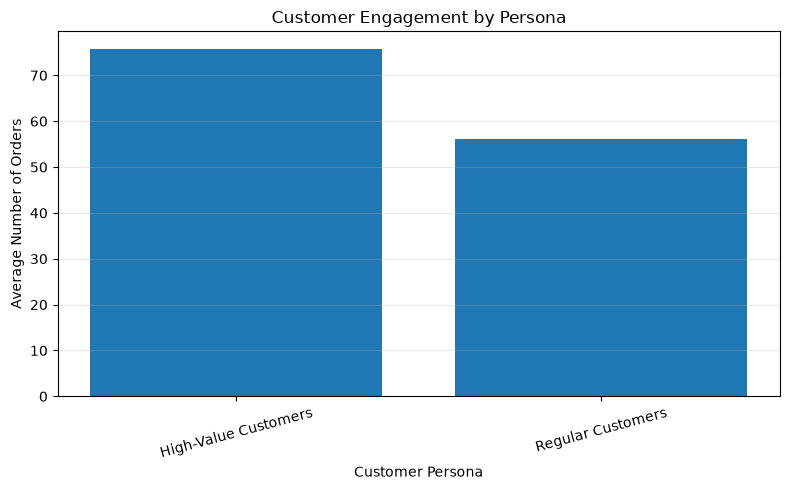

Persona engagement chart created successfully!


In [6]:
# Compare customer engagement across personas

plt.figure(figsize=(8, 5))

plt.bar(
    persona_profile.index,
    persona_profile["average_orders"]
)

plt.xlabel("Customer Persona")
plt.ylabel("Average Number of Orders")
plt.title("Customer Engagement by Persona")

plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "persona_engagement.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Persona engagement chart created successfully!")

In [7]:
# Create a customer persona summary table

persona_summary = persona_profile[
    [
        "average_sales",
        "average_quantity",
        "average_profit",
        "average_discount",
        "average_shipping_days",
        "average_orders",
        "customer_count"
    ]
].copy()

persona_summary = persona_summary.rename(columns={
    "average_sales": "Average Sales",
    "average_quantity": "Average Quantity",
    "average_profit": "Average Profit",
    "average_discount": "Average Discount",
    "average_shipping_days": "Average Shipping Days",
    "average_orders": "Average Orders",
    "customer_count": "Customer Count"
})

print("========== CUSTOMER PERSONA SUMMARY ==========\n")

display(persona_summary)


========== CUSTOMER PERSONA SUMMARY ==========



,Average Sales,Average Quantity,Average Profit,Average Discount,Average Shipping Days,Average Orders,Customer Count
segment_name,,,,,,,
High-Value Customers,20109.22,267.53,2616.06,0.14,3.95,75.81,338
Regular Customers,12792.09,192.31,1279.66,0.15,3.99,56.16,457


In [8]:
# Create business-friendly descriptions for each persona

persona_descriptions = {}

high_sales_persona = persona_profile["average_sales"].idxmax()
high_orders_persona = persona_profile["average_orders"].idxmax()

for persona in persona_profile.index:

    if persona == high_sales_persona and persona == high_orders_persona:
        description = (
            "High-value and highly engaged customers "
            "with strong purchasing activity."
        )

    elif persona == high_sales_persona:
        description = (
            "Customers with higher spending levels "
            "and strong contribution to sales."
        )

    elif persona == high_orders_persona:
        description = (
            "Customers who purchase frequently "
            "and show strong engagement."
        )

    else:
        description = (
            "Customers with comparatively lower "
            "spending or purchasing frequency."
        )

    persona_descriptions[persona] = description

print("========== PERSONA DESCRIPTIONS ==========\n")

for persona, description in persona_descriptions.items():
    print(persona)
    print("-", description)
    print()

========== PERSONA DESCRIPTIONS ==========

High-Value Customers
- High-value and highly engaged customers with strong purchasing activity.

Regular Customers
- Customers with comparatively lower spending or purchasing frequency.



In [9]:
# Create business strategies for each customer persona

persona_strategy = {}

for persona in persona_profile.index:

    if persona == high_sales_persona:
        strategy = (
            "Focus on customer retention, loyalty rewards, "
            "personalized offers, and premium recommendations."
        )

    elif persona == high_orders_persona:
        strategy = (
            "Encourage continued engagement through targeted "
            "promotions, product recommendations, and repeat-purchase offers."
        )

    else:
        strategy = (
            "Use targeted discounts, personalized promotions, "
            "and recommendations to increase purchase frequency."
        )

    persona_strategy[persona] = strategy

print("========== BUSINESS STRATEGIES ==========\n")

for persona, strategy in persona_strategy.items():

    print(persona)
    print("-", strategy)
    print()

========== BUSINESS STRATEGIES ==========

High-Value Customers
- Focus on customer retention, loyalty rewards, personalized offers, and premium recommendations.

Regular Customers
- Use targeted discounts, personalized promotions, and recommendations to increase purchase frequency.



In [10]:
# Create the final customer persona report

report = "# Day 31 - Customer Persona Analysis\n\n"

report += "## Objective\n\n"
report += (
    "The objective of Day 31 was to transform customer clustering "
    "results into meaningful customer personas using behavioral data.\n\n"
)

report += "## Persona Analysis\n\n"

for persona in persona_profile.index:

    row = persona_profile.loc[persona]

    report += f"### {persona}\n\n"

    report += f"- Customer Count: {int(row['customer_count'])}\n"
    report += f"- Average Sales: {row['average_sales']}\n"
    report += f"- Average Quantity: {row['average_quantity']}\n"
    report += f"- Average Profit: {row['average_profit']}\n"
    report += f"- Average Discount: {row['average_discount']}\n"
    report += f"- Average Shipping Days: {row['average_shipping_days']}\n"
    report += f"- Average Orders: {row['average_orders']}\n\n"

    report += "**Persona Description:**\n\n"
    report += f"{persona_descriptions[persona]}\n\n"

    report += "**Recommended Business Strategy:**\n\n"
    report += f"{persona_strategy[persona]}\n\n"

report += "## Conclusion\n\n"
report += (
    "Customer personas help businesses understand different behavioral "
    "patterns and create more targeted retention, promotion, and "
    "personalization strategies.\n"
)

with open(
    "customer_persona_report.md",
    "w",
    encoding="utf-8"
) as file:
    file.write(report)

print("Customer persona report created successfully!")
print("File: customer_persona_report.md")

Customer persona report created successfully!
File: customer_persona_report.md


In [11]:
# Save the customer persona summary

persona_summary.to_csv(
    "customer_persona_summary.csv"
)

print("Customer persona summary saved successfully!")
print("File: customer_persona_summary.csv")

Customer persona summary saved successfully!
File: customer_persona_summary.csv


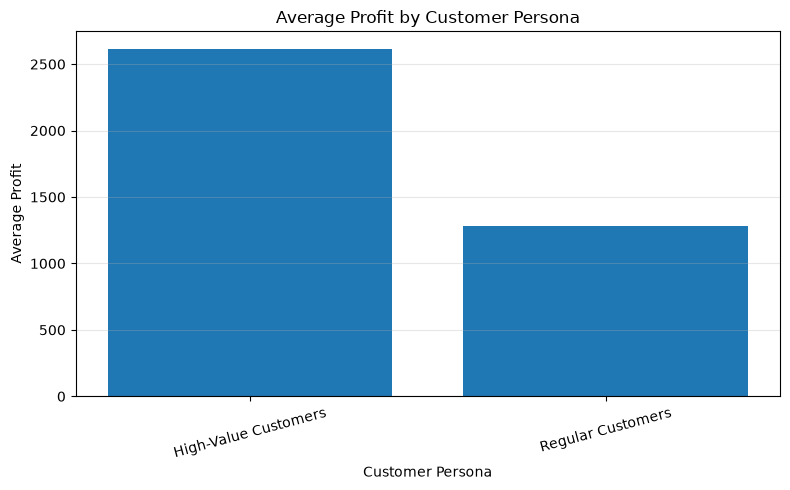

Persona profit chart created successfully!


In [12]:
# Visualize average profit by customer persona

plt.figure(figsize=(8, 5))

plt.bar(
    persona_profile.index,
    persona_profile["average_profit"]
)

plt.xlabel("Customer Persona")
plt.ylabel("Average Profit")
plt.title("Average Profit by Customer Persona")

plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "persona_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Persona profit chart created successfully!")

In [13]:
# Check all Day 31 output files

import os

files = [
    "day31.ipynb",
    "persona_spending.png",
    "persona_engagement.png",
    "persona_profit.png",
    "customer_persona_summary.csv",
    "customer_persona_report.md"
]

print("========== DAY 31 FILE CHECK ==========\n")

for file in files:
    if os.path.exists(file):
        print("✅", file)
    else:
        print("❌", file, "NOT FOUND")

========== DAY 31 FILE CHECK ==========

✅ day31.ipynb
✅ persona_spending.png
✅ persona_engagement.png
✅ persona_profit.png
✅ customer_persona_summary.csv
✅ customer_persona_report.md
